In [119]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
from pathlib import Path
import plotly.express as px
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

import logging
logger = logging.getLogger(__name__)

In [120]:
logging.basicConfig(format='%(asctime)s|%(levelname)s|%(message)s',
                    # filename='output.log', 
                    encoding='utf-8', 
                    level=logging.DEBUG)
logger = logging.getLogger(__name__)

In [121]:
class ContrastiveLossEmbeddingModel(nn.Module):
    """
    Implements the ContrastiveLossEmbeddingModel.
    Implementation is nearly identical to TripletLossEmbeddingModel
    """
    def __init__(self, input_dim, embed_dim):
        super(ContrastiveLossEmbeddingModel, self).__init__()
        # Create the shared embedding layer
        self.embedding = nn.Linear(input_dim, embed_dim)

    def forward(self, x):
        # Compute embeddings
        return F.normalize(self.embedding(x), p=2, dim=1)

In [122]:
class ContrastiveDataset(Dataset):
    """
    Implement contrastive dataset class.
    """
    def __init__(self, x1, x2, labels):
        assert x1.shape == x2.shape
        assert len(labels) == len(x1)
        self.num_samples, self.input_dim = x1.shape
        self.x1 = x1
        self.x2 = x2
        self.labels = labels
        
    def __len__(self):
        return self.num_samples
    
    def __getitem__(self, idx):
        return (
            torch.tensor(self.x1[idx].detach().clone(), dtype=torch.float32),
            torch.tensor(self.x2[idx].detach().clone(), dtype=torch.float32),
            torch.tensor(self.labels[idx].detach().clone(), dtype=torch.float32)
        )

In [123]:
class ContrastiveLoss(nn.Module):
    """
    Because PyTorch does not have a built-in contrastive loss function, we create one.
    """
    def __init__(self, margin=1.0, dist_func=None):
        super(ContrastiveLoss, self).__init__()
        self.margin = margin

        if dist_func is None:
            self.dist_func = F.pairwise_distance
        else:
            self.dist_func = dist_func

    def forward(self, output1, output2, label):
        distances = self.dist_func(output1, output2)
        loss = torch.mean(label * distances.pow(2) +
                          (1 - label) * F.relu(self.margin - distances).pow(2))
        return loss

In [124]:
def cosine_distance(x1, x2):
    """
    Implement a cosine_distance function as PyTorch does not have a built-in one.
    """
    x1 = F.normalize(x1, p=2, dim=1)
    x2 = F.normalize(x2, p=2, dim=1)
    cosine_sim = torch.sum(x1 * x2, dim=1)
    return 1 - cosine_sim  # convert similarity to distance


def train_contrastive_loss(dataset, embed_dim,
                       dist_func=None,
                       margin=1.0,
                       batch_size=256,
                       epochs=10,
                       lr=0.001
                       ):
    """
    Training loop for triplet margin loss.

    Args:
        dataset (ContrastiveLossDataset) : The training dataset.
        embed_dim (int) : The size of the embedding vectors.
        dist_func (callable) : If using custom distance function (default is Euclidean distance).
        margin (float) : The size of the margin learned (larger forces more separation between positive and negative).
        batch_size (int) : Training batch size.
        epochs (int) : Training epochs.
        lr (float) : The learning rate.

    Returns:
        model (ContrastiveLossEmbeddingModel) : The trained model.
        loss (np.array(float)) : The training loss for each epoch.
    """

    input_dim = dataset.input_dim
    model = ContrastiveLossEmbeddingModel(input_dim, embed_dim)

    # Create loss function module
    criterion = ContrastiveLoss(margin, dist_func)

    # Init optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    # Training loop
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    loss_history = np.zeros(epochs)
    for i_e, epoch in enumerate(range(epochs)):
        total_loss = 0
        for x1, x2, labels in dataloader:
            optimizer.zero_grad()
            # Forward pass
            x1_embed = model(x1)
            x2_embed = model(x2)
            # Compute loss
            loss = criterion(x1_embed, x2_embed, labels)
            # Backpropagation
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        loss_history[i_e] = total_loss/len(dataloader)
        
        logging.debug(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(dataloader):.4f}")

    return model, loss_history
    

In [125]:

def vectorize(series):
    """
    Takes a pandas Series of embedding_json strings
    and returns a NumPy array of shape (N, 384).
    """
    # Ensure string
    s = series.astype(str).str.strip()

    # Remove brackets, split into float lists
    vecs = (
        s.str[1:-1]                   # strip '[' and ']'
         .str.split(',')              # split by comma
         .apply(lambda x: np.array(x, dtype=np.float32))
         .tolist()
    )

    # Stack into (n_samples, embed_dim)
    return np.vstack(vecs)

In [126]:
global_db = pd.read_csv('/data/elugos/global_db_111125.csv')
df_train_sample = pd.read_csv(Path('/data/elugos/train_data.csv'))

In [127]:
def clean_sample(df,global_db):
    ## get longest sbert text
    df["text_len"] = df["sbert_text"].str.len()
    df_clean = df.sort_values("text_len", ascending=False).drop_duplicates(subset="GlobalEventID", keep="first")
    df_clean = df_clean.drop(columns=["text_len"])
    ## get all rows that exist in df from global_db and clean to make sure they match, drop all other rows
    ids = df_clean["GlobalEventID"]
    global_play_db = global_db[global_db["GlobalEventID"].isin(ids)].copy()
    valid_ids = set(global_play_db["GlobalEventID"])
    df_clean = df_clean[df_clean["GlobalEventID"].isin(valid_ids)].copy()
    ## add globaldb to df_clean
    df_clean = df_clean.merge(
    global_play_db,
    on="GlobalEventID",
    how="left",
    suffixes=("", "_db")
)

    return df_clean,global_play_db

In [128]:
df_train_sample,global_play_db = clean_sample(df_train_sample,global_db)


In [129]:
cameo_codes = {
    "MAKE PUBLIC STATEMENT": "1",
    "APPEAL": "2",
    "EXPRESS INTENT TO COOPERATE": "3",
    "CONSULT": "4",
    "ENGAGE IN DIPLOMATIC COOPERATION": "5",
    "ENGAGE IN MATERIAL COOPERATION": "6",
    "PROVIDE AID": "7",
    "YIELD": "8",
    "INVESTIGATE": "9",
    "DEMAND": "10",
    "DISAPPROVE": "11",
    "REJECT": "12",
    "THREATEN": "13",
    "PROTEST": "14",
    "EXHIBIT FORCE POSTURE": "15",
    "COERCE": "16",
    "ASSAULT": "17",
    "FIGHT": "19",
    "USE UNCONVENTIONAL MASS VIOLENCE": "20",
}

In [130]:
def make_sampler(df,num):
    # sample i and j
    i = df.sample(n=num, random_state=42, replace=True)
    j = df.sample(n=num, random_state=1, replace=True)
    # This may (albeit unlikely) generate samples where i==j, which is fine, since that would imply the events are the same.
    # Alternatively, we can safely drop those samples, if needed.

    # remaining = df.drop(i.index)
    # j = remaining.sample(n=num, random_state=43, relace)

    # reset index so pairs line up
    i = i.reset_index(drop=True)
    j = j.reset_index(drop=True)

    # Extract only the FIRST part of EventCode (before underscore)
    i_event_major = i["EventCode"].astype(str).str.split("_").str[-1]
    j_event_major = j["EventCode"].astype(str).str.split("_").str[-1]

    # Build sampler
    sampler = pd.DataFrame({
        "GlobalEventID-i": i["GlobalEventID"],
        "GlobalEventID-j": j["GlobalEventID"],
        "embedding_json-i": i["embedding_json"],
        "embedding_json-j": j["embedding_json"],
        "EventCode-i": i_event_major,
        "EventCode-j": j_event_major
    })

    # y = 1 if the FIRST XX match, else 0
    sampler["y"] = (i_event_major.values == j_event_major.values).astype(int)

    return sampler




In [205]:
n_training = 100000
sampler = make_sampler(df_train_sample,n_training)

print(f"Input training data: {len(df_train_sample)} articles.")
print(f"Training pairs: {len(sampler)}")
print(f"  {sampler.value_counts('y')}")

Input training data: 73344 articles.
Training pairs: 100000
  y
0    89740
1    10260
Name: count, dtype: int64


In [206]:


i_np = vectorize(sampler["embedding_json-i"])
j_np = vectorize(sampler["embedding_json-j"])

i = torch.from_numpy(i_np)
j = torch.from_numpy(j_np)
# Random labels: 0 if dissimilar, 1 if similar.
#make the labels if similar 1, 0 if not
labels = torch.tensor(sampler["y"].values, dtype=torch.float32)

logger.info(f"{i.shape}, {j.shape}, {labels.shape}")


2025-12-10 16:09:48,876|INFO|torch.Size([100000, 384]), torch.Size([100000, 384]), torch.Size([100000])


In [ ]:
input_dim = 384  # Just like SBERT embeddings
embed_dim = 300  # Chosen embedding dimension
margin = 1.0  # Choose a margin
batch_size=512  # the batch size
n_epochs = 30  # the number of epochs
lr = 0.1  # the learning rate

dataset = ContrastiveDataset(i, j, labels)
model, loss = train_contrastive_loss(dataset, embed_dim, margin=margin,
                                     dist_func=cosine_distance, 
                                     batch_size=batch_size,
                                     epochs=n_epochs,
                                     lr=lr
                                     )
logger.info(f"Model trained!")


/tmp/ipykernel_1961978/418015968.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(self.x1[idx].detach().clone(), dtype=torch.float32),
/tmp/ipykernel_1961978/418015968.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(self.x2[idx].detach().clone(), dtype=torch.float32),
/tmp/ipykernel_1961978/418015968.py:20: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(self.labels[idx].detach().clone(), dtype=torch.float32)
2025-12-10 16:03:48,811|DEBUG|Epoch 1/30, Loss: 0.1173
2025-12-10 16:03:58,419|DEBUG|

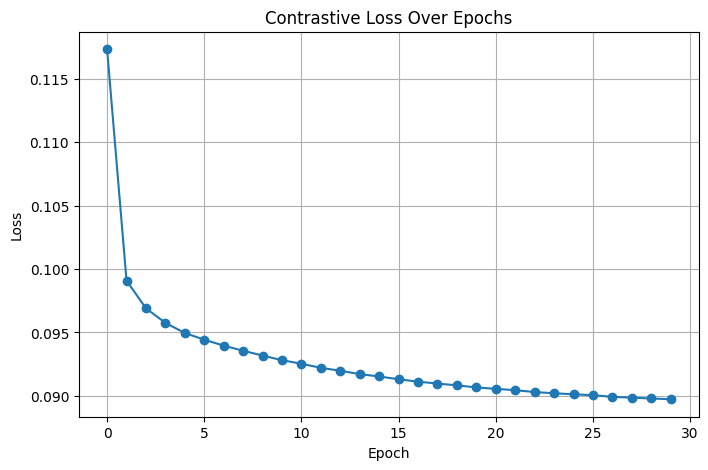

In [197]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(loss, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Contrastive Loss Over Epochs")
plt.grid(True)
plt.show()

In [198]:
# merge metadata for i
meta_i = sampler[["GlobalEventID-i"]].merge(
    global_db[["GlobalEventID", "EventCode"]],
    left_on="GlobalEventID-i",
    right_on="GlobalEventID",
    how="left"
).drop(columns=["GlobalEventID"]).rename(columns={"EventCode": "EventCode-i"})

# merge metadata for j
meta_j = sampler[["GlobalEventID-j"]].merge(
    global_db[["GlobalEventID", "EventCode"]],
    left_on="GlobalEventID-j",
    right_on="GlobalEventID",
    how="left"
).drop(columns=["GlobalEventID"]).rename(columns={"EventCode": "EventCode-j"})


In [199]:
def avg_pairwise_distance_by_label(x1, x2, labels, metric="cosine"):
    """
    Works with BOTH numpy arrays and torch tensors.
    Computes avg distance for same-label and opposite-label pairs.
    """

    # --- Convert everything to torch tensors if needed ---
    if isinstance(x1, np.ndarray):
        x1 = torch.from_numpy(x1)
    if isinstance(x2, np.ndarray):
        x2 = torch.from_numpy(x2)
    if isinstance(labels, np.ndarray):
        labels = torch.from_numpy(labels)

    x1 = x1.float()
    x2 = x2.float()
    labels = labels.int()

    # --- Distance computation ---
    if metric == "cosine":
        x1n = F.normalize(x1, p=2, dim=1)
        x2n = F.normalize(x2, p=2, dim=1)
        distances = 1 - torch.sum(x1n * x2n, dim=1)

    elif metric == "euclidean":
        distances = torch.norm(x1 - x2, dim=1)

    else:
        raise ValueError("metric must be 'cosine' or 'euclidean'")

    distances = distances.cpu().numpy()
    labels = labels.cpu().numpy()

    same_mask = labels == 1
    opp_mask  = labels == 0

    same_dist = distances[same_mask]
    opp_dist = distances[opp_mask]

    avg_same = distances[same_mask].mean() if same_mask.any() else np.nan
    avg_opp  = distances[opp_mask].mean() if opp_mask.any() else np.nan

    return same_dist, opp_dist,{
        "avg_same": float(avg_same),
        "avg_opposite": float(avg_opp),
        "n_same": int(same_mask.sum()),
        "n_opposite": int(opp_mask.sum())
    }

In [200]:
model.eval()

with torch.no_grad():
    i_embed = model(i).cpu().numpy()   # shape: (N, embed_dim)
    j_embed = model(j).cpu().numpy()   # shape: (N, embed_dim)
    
all_embeddings = np.vstack([i_embed, j_embed])

global_ids = np.concatenate([sampler["GlobalEventID-i"].values,
                             sampler["GlobalEventID-j"].values])

eventcodes = np.concatenate([
    meta_i["EventCode-i"].astype(str).str.rsplit("_", n=1).str[-1].values,
    meta_j["EventCode-j"].astype(str).str.rsplit("_", n=1).str[-1].values
])


all_labels = np.concatenate([labels.numpy(), labels.numpy()])
pair_flag   = np.array([0]*len(i_embed) + [1]*len(j_embed))  # blue = i, orange = j


In [201]:
sbert_same_dist, sbert_opp_dist, stats_sbert_35000 = avg_pairwise_distance_by_label(i, j, labels, metric="cosine")

# Learned embeddings
learned_same_dist, learn_opp_dist, stats_learned_35000 = avg_pairwise_distance_by_label(i_embed, j_embed, labels, metric="cosine")

In [202]:
stats_learned_35000

{'avg_same': 0.8361701369285583,
 'avg_opposite': 0.9083757996559143,
 'n_same': 52123,
 'n_opposite': 447877}

In [203]:
stats_sbert_35000

{'avg_same': 0.9204286932945251,
 'avg_opposite': 0.921503484249115,
 'n_same': 52123,
 'n_opposite': 447877}

In [204]:
# Sample data for testing

# Get event ids used in training and remove them from the test
training_event_ids = set(list(sampler['GlobalEventID-i'].unique()) + list(sampler['GlobalEventID-j']))
df_test_sample = df_train_sample[~df_train_sample['GlobalEventID'].isin(training_event_ids)]
print(f"Found {len(df_test_sample)} samples not seen in training.")

sample_test = make_sampler(df_test_sample, 1000)

# merge metadata for i
meta_i = sample_test[["GlobalEventID-i"]].merge(
    global_db[["GlobalEventID", "EventCode"]],
    left_on="GlobalEventID-i",
    right_on="GlobalEventID",
    how="left"
).drop(columns=["GlobalEventID"]).rename(columns={"EventCode": "EventCode-i"})

# merge metadata for j
meta_j = sample_test[["GlobalEventID-j"]].merge(
    global_db[["GlobalEventID", "EventCode"]],
    left_on="GlobalEventID-j",
    right_on="GlobalEventID",
    how="left"
).drop(columns=["GlobalEventID"]).rename(columns={"EventCode": "EventCode-j"})

Found 0 samples not seen in training.


ValueError: a must be greater than 0 unless no samples are taken

In [189]:
i_np = vectorize(sample_test["embedding_json-i"])
j_np = vectorize(sample_test["embedding_json-j"])

i_test = torch.from_numpy(i_np)
j_test = torch.from_numpy(j_np)
# Random labels: 0 if dissimilar, 1 if similar.
#make the labels if similar 1, 0 if not
labels_test = torch.tensor(sample_test["y"].values, dtype=torch.float32)

logger.info(f"{i_test.shape}, {j_test.shape}, {labels_test.shape}")

2025-12-10 15:59:17,823|INFO|torch.Size([1000, 384]), torch.Size([1000, 384]), torch.Size([1000])


In [190]:
model.eval()

with torch.no_grad():
    i_embed_test = model(i_test).cpu().numpy()   # shape: (N, embed_dim)
    j_embed_test = model(j_test).cpu().numpy()   # shape: (N, embed_dim)
    
all_embeddings = np.vstack([i_embed_test, j_embed_test])

global_ids = np.concatenate([sample_test["GlobalEventID-i"].values,
                             sample_test["GlobalEventID-j"].values])

eventcodes = np.concatenate([
    meta_i["EventCode-i"].astype(str).str.rsplit("_", n=1).str[-1].values,
    meta_j["EventCode-j"].astype(str).str.rsplit("_", n=1).str[-1].values
])


all_labels = np.concatenate([labels_test.numpy(), labels_test.numpy()])
pair_flag   = np.array([0]*len(i_embed_test) + [1]*len(j_embed_test))  # blue = i, orange = j

In [191]:
test_sbert_same_dist, test_sbert_opp_dist, test_stats_sbert_35000 = avg_pairwise_distance_by_label(i_test, j_test, labels_test, metric="cosine")

# Learned embeddings
test_learned_same_dist, test_learn_opp_dist, test_stats_learned_35000 = avg_pairwise_distance_by_label(i_embed_test, j_embed_test, labels_test, metric="cosine")

In [192]:
print(test_stats_learned_35000)

{'avg_same': 0.9778667688369751, 'avg_opposite': 0.9983106851577759, 'n_same': 130, 'n_opposite': 870}


In [ ]:
#np.savetxt('sbert_same_euc_64_1.csv', sbert_same_dist, delimiter=',')
#np.savetxt('sbert_opp_euc_64_1.csv', sbert_opp_dist, delimiter=',')
np.savetxt('learned_same_cos_64_1.csv', learned_same_dist, delimiter=',')
np.savetxt('learned_opp_cos_64_1.csv', learn_opp_dist, delimiter=',')

np.savetxt('test_learned_same_cos_64_1.csv', test_learned_same_dist, delimiter=',')
np.savetxt('test_learned_opp_cos_64_1.csv', test_learn_opp_dist, delimiter=',')

In [ ]:
from datetime import datetime

torch.save({
    "model_state_dict": model.state_dict(),
    "input_dim": input_dim,
    "embed_dim": embed_dim,
    "margin": margin,
    "epochs": n_epochs,
    "date": datetime.now().strftime("%Y%m%dT%H%M%S")
}, "contrastive_64_1.pt")

In [ ]:
emb2d_tsne = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(all_embeddings)

emb2d_pca = PCA(n_components=2).fit_transform(all_embeddings)


In [ ]:
df_plot = pd.DataFrame({
    "x": emb2d_tsne[:,0],
    "y": emb2d_tsne[:,1],
    "GlobalEventID": global_ids,
    
    "EventCode": eventcodes.astype(int)
})

fig = px.scatter(
    df_plot,
    x="x",
    y="y",
    color="EventCode",
    hover_data=["GlobalEventID", "EventCode"],
    title="Learned Embeddings Colored by EventCode"
)

fig.update_traces(marker=dict(size=6, opacity=0.85))
fig.update_layout(width=900, height=600)
fig.show()

In [ ]:
df_plot = pd.DataFrame({
    "x": emb2d_pca[:,0],
    "y": emb2d_pca[:,1],
    "GlobalEventID": global_ids,
    
    "EventCode": eventcodes.astype(int)
})

fig = px.scatter(
    df_plot,
    x="x",
    y="y",
    color="EventCode",
    hover_data=["GlobalEventID", "EventCode"],
    title="Learned Embeddings Colored by EventCode"
)

fig.update_traces(marker=dict(size=6, opacity=0.85))
fig.update_layout(width=900, height=600)
fig.show()